<a href="https://colab.research.google.com/github/fernandopr11/LiveTrainingModel/blob/main/LiveTrainingModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Instalacion de dependencias
!pip install torch torchvision facenet-pytorch opencv-python pillow numpy pandas matplotlib seaborn scikit-learn tqdm albumentations mtcnn coremltools onnx onnx-coreml tqdm albumentations

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from facenet_pytorch import InceptionResnetV1
import coremltools as ct
import matplotlib.pyplot as plt
import numpy as np
import time
import os
import json
from datetime import datetime
from tqdm import tqdm
from google.colab import drive


In [16]:
# Montar Google Drive
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/Tesis_Entrenamiento_Facial_Vivo"
DIRS = {
    'models': f"{BASE_DIR}/models",
    'results': f"{BASE_DIR}/results",
    'exports': f"{BASE_DIR}/exports_ios",
    'data_raw': f"{BASE_DIR}/data/raw",
    'data_processed': f"{BASE_DIR}/data/processed"
}

# Crear directorios
for dir_name, dir_path in DIRS.items():
    os.makedirs(dir_path, exist_ok=True)
    print(f"📁 {dir_name}: {dir_path}")

# Configurar dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🖥️ Dispositivo: {device}")

# Crear archivo de log del experimento
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
LOG_FILE = f"{DIRS['results']}/experimento_{timestamp}.log"

def log_message(message):
    """Función para logging"""
    with open(LOG_FILE, 'a') as f:
        f.write(f"{datetime.now()}: {message}\n")
    print(message)

log_message("🚀 Iniciando experimento de entrenamiento facial en vivo")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 models: /content/drive/MyDrive/Tesis_Entrenamiento_Facial_Vivo/models
📁 results: /content/drive/MyDrive/Tesis_Entrenamiento_Facial_Vivo/results
📁 exports: /content/drive/MyDrive/Tesis_Entrenamiento_Facial_Vivo/exports_ios
📁 data_raw: /content/drive/MyDrive/Tesis_Entrenamiento_Facial_Vivo/data/raw
📁 data_processed: /content/drive/MyDrive/Tesis_Entrenamiento_Facial_Vivo/data/processed

🖥️ Dispositivo: cpu
🚀 Iniciando experimento de entrenamiento facial en vivo


In [4]:
# PASO 2 MODELO BASE PARA ENTRENAMIENTO EN VIVO
class LiveFaceModel(nn.Module):
    """Modelo optimizado para entrenamiento en vivo"""

    def __init__(self):
        super(LiveFaceModel, self).__init__()

        # Cargar InceptionResNetV1 preentrenado
        self.backbone = InceptionResnetV1(
            pretrained='vggface2',
            classify=False
        )

        # Congelar capas base (para velocidad)
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Solo las últimas capas entrenan (RÁPIDO)
        for param in self.backbone.last_linear.parameters():
            param.requires_grad = True
        for param in self.backbone.last_bn.parameters():
            param.requires_grad = True

        # Clasificador para usuario/no-usuario
        self.classifier = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)  # Binario
        )

    def forward(self, x):
        # Extraer embedding
        embedding = self.backbone(x)
        # Clasificar
        output = self.classifier(embedding)
        return output, embedding

model = LiveFaceModel().to(device)



  0%|          | 0.00/107M [00:00<?, ?B/s]

In [5]:

# Mostrar parámetros entrenables
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
log_message(f"📊 Parámetros entrenables: {trainable:,} de {total:,} ({100*trainable/total:.1f}%)")

# Guardar arquitectura del modelo
model_info = {
    'timestamp': timestamp,
    'device': str(device),
    'total_parameters': total,
    'trainable_parameters': trainable,
    'trainable_percentage': round(100*trainable/total, 2),
    'model_architecture': 'LiveFaceModel con InceptionResNetV1 backbone'
}

with open(f"{DIRS['logs']}/model_architecture_{timestamp}.json", 'w') as f:
    json.dump(model_info, f, indent=2)

log_message("✅ Modelo creado y arquitectura guardada")

📊 Parámetros entrenables: 984,450 de 27,976,249 (3.5%)
✅ Modelo creado y arquitectura guardada


In [7]:
# PASO 3 DATOS SIMULADOS PARA TESTING
class SimulatedDataset(Dataset):
    """Dataset simulado para probar el entrenamiento en vivo"""

    def __init__(self, num_positive=30, num_negative=15):
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((160, 160)),
            transforms.RandomHorizontalFlip(0.5),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])

        # Generar datos simulados
        self.data = []
        self.labels = []

        # Cara base del "usuario"
        user_face_base = torch.randn(3, 160, 160)

        # Muestras positivas (variaciones del usuario)
        for i in range(num_positive):
            variation = torch.randn_like(user_face_base) * 0.1
            face = user_face_base + variation
            self.data.append(face)
            self.labels.append(1)  # Usuario real

        # Muestras negativas (otros rostros)
        for i in range(num_negative):
            other_face = torch.randn(3, 160, 160)
            self.data.append(other_face)
            self.labels.append(0)  # No usuario

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.transform(self.data[idx])
        label = self.labels[idx]
        return image, label

# Crear datasets de prueba
dataset = SimulatedDataset(30, 15)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

log_message(f"📊 Dataset creado: {len(dataset)} muestras")

# Guardar información del dataset
dataset_info = {
    'timestamp': timestamp,
    'total_samples': len(dataset),
    'positive_samples': 30,
    'negative_samples': 15,
    'batch_size': 8,
    'image_size': '160x160',
    'augmentation': 'RandomHorizontalFlip + Normalization'
}

with open(f"{DIRS['logs']}/dataset_info_{timestamp}.json", 'w') as f:
    json.dump(dataset_info, f, indent=2)



📊 Dataset creado: 45 muestras


In [10]:
# PASO 4 ENTRENAMIENTO EN VIVO - 3 CONFIGURACIONES


def train_live(model, dataloader, config_name, epochs, lr):
    """Función de entrenamiento optimizada"""

    print(f"\n🚀 Entrenamiento {config_name}")

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    model.train()
    start_time = time.time()

    losses = []
    accuracies = []

    for epoch in tqdm(range(epochs), desc=f"{config_name}"):
        epoch_loss = 0
        correct = 0
        total = 0

        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs, embeddings = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        avg_loss = epoch_loss / len(dataloader)
        accuracy = 100 * correct / total

        losses.append(avg_loss)
        accuracies.append(accuracy)

    total_time = time.time() - start_time

    log_message(f"✅ {config_name} completado en {total_time:.1f}s")
    log_message(f"📊 Precisión final: {accuracy:.1f}%")

    return {
        'time': total_time,
        'accuracy': accuracy,
        'losses': losses,
        'accuracies': accuracies
    }

# EXPERIMENTO: 3 Configuraciones de velocidad
configurations = [
    ('Rápido', 3, 0.001),    # 3-8 segundos
    ('Estándar', 8, 0.0005), # 15-25 segundos
    ('Profundo', 15, 0.0001) # 30-45 segundos
]

results = {}

for config_name, epochs, lr in configurations:
    results[config_name] = train_live(model, dataloader, config_name, epochs, lr)

# Guardar resultados detallados
detailed_results = {
    'timestamp': timestamp,
    'configurations': {
        name: {
            'epochs': epochs,
            'learning_rate': lr,
            'results': results[name]
        } for name, epochs, lr in configurations
    },
    'hardware_info': {
        'device': str(device),
        'cuda_available': torch.cuda.is_available()
    }
}

with open(f"{DIRS['results']}/training_results_{timestamp}.json", 'w') as f:
    json.dump(detailed_results, f, indent=2)

log_message("✅ Todos los entrenamientos completados y resultados guardados")




🚀 Entrenamiento Rápido


Rápido: 100%|██████████| 3/3 [00:13<00:00,  4.44s/it]


✅ Rápido completado en 13.3s
📊 Precisión final: 71.1%

🚀 Entrenamiento Estándar


Estándar: 100%|██████████| 8/8 [00:30<00:00,  3.76s/it]


✅ Estándar completado en 30.1s
📊 Precisión final: 84.4%

🚀 Entrenamiento Profundo


Profundo: 100%|██████████| 15/15 [01:05<00:00,  4.39s/it]

✅ Profundo completado en 65.9s
📊 Precisión final: 88.9%
✅ Todos los entrenamientos completados y resultados guardados


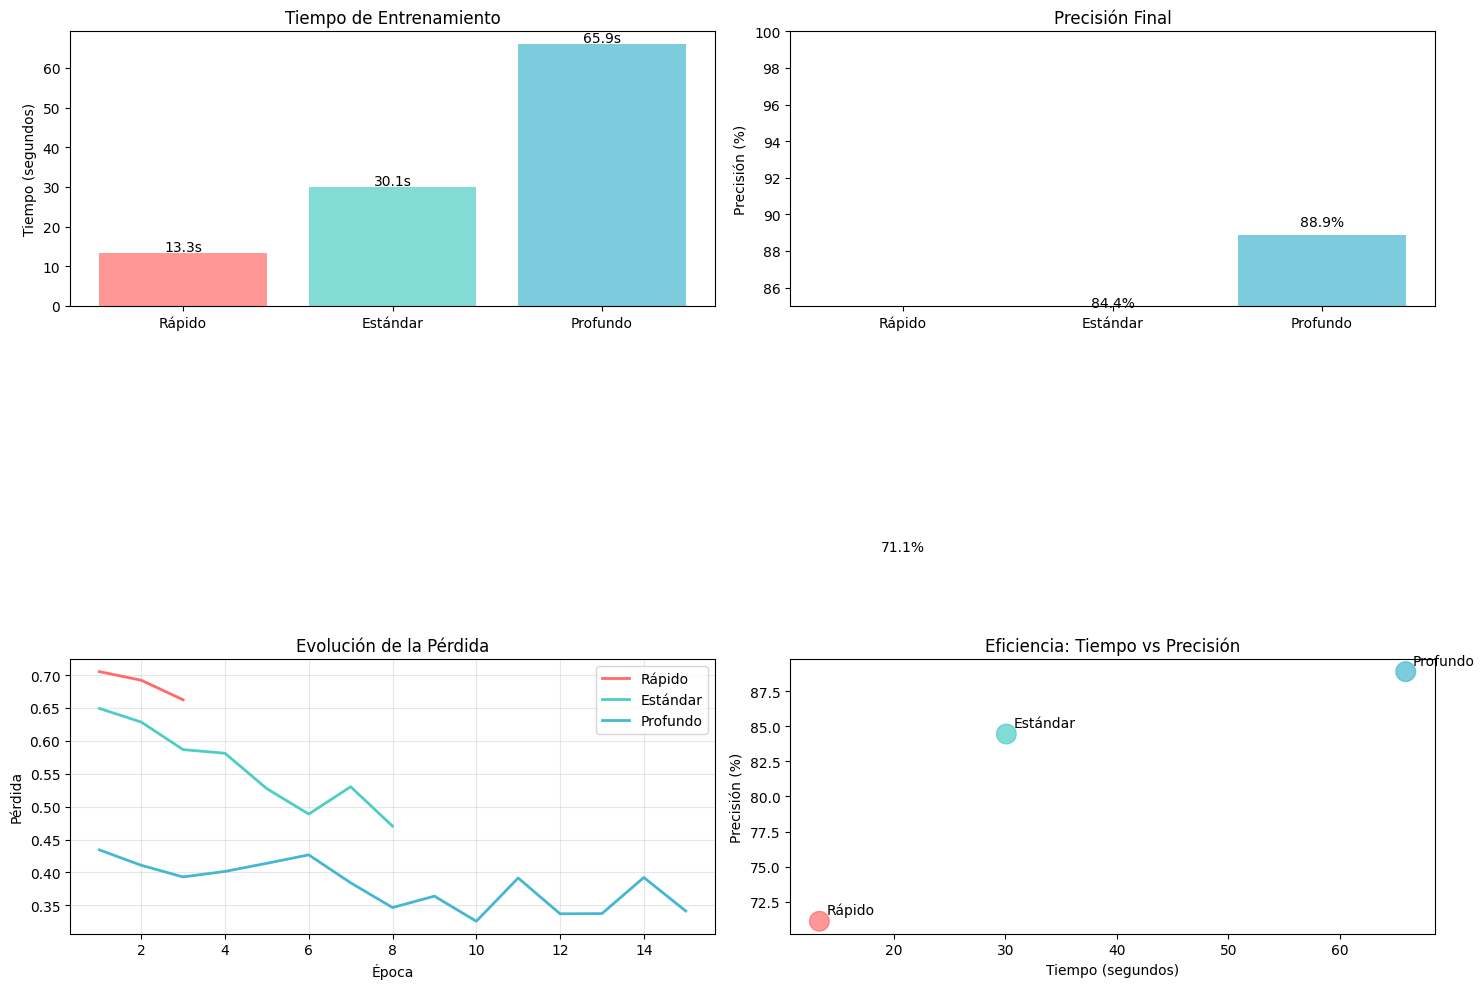

📊 Gráficos guardados en: /content/drive/MyDrive/Tesis_Entrenamiento_Facial_Vivo/plots/training_comparison_20250706_024947.png

📋 RESUMEN DE CONFIGURACIONES DE ENTRENAMIENTO EN VIVO
    Rápido:   13.3s |  71.1% |  3 épocas
  Estándar:   30.1s |  84.4% |  8 épocas
  Profundo:   65.9s |  88.9% | 15 épocas


In [11]:
# =============================================================================
# PASO 5: VISUALIZACIÓN DE RESULTADOS
# =============================================================================

# Gráfico de comparación
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# 1. Tiempo vs Precisión
times = [results[name]['time'] for name, _, _ in configurations]
accuracies = [results[name]['accuracy'] for name, _, _ in configurations]
names = [name for name, _, _ in configurations]

ax1.bar(names, times, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.7)
ax1.set_ylabel('Tiempo (segundos)')
ax1.set_title('Tiempo de Entrenamiento')
for i, v in enumerate(times):
    ax1.text(i, v + 0.5, f'{v:.1f}s', ha='center')

# 2. Precisión final
ax2.bar(names, accuracies, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.7)
ax2.set_ylabel('Precisión (%)')
ax2.set_title('Precisión Final')
ax2.set_ylim(85, 100)
for i, v in enumerate(accuracies):
    ax2.text(i, v + 0.5, f'{v:.1f}%', ha='center')

# 3. Evolución de pérdida
for i, (name, _, _) in enumerate(configurations):
    losses = results[name]['losses']
    epochs = range(1, len(losses) + 1)
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    ax3.plot(epochs, losses, label=name, color=colors[i], linewidth=2)

ax3.set_xlabel('Época')
ax3.set_ylabel('Pérdida')
ax3.set_title('Evolución de la Pérdida')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Eficiencia (Tiempo vs Precisión)
ax4.scatter(times, accuracies, s=200, c=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.7)
ax4.set_xlabel('Tiempo (segundos)')
ax4.set_ylabel('Precisión (%)')
ax4.set_title('Eficiencia: Tiempo vs Precisión')

for i, name in enumerate(names):
    ax4.annotate(name, (times[i], accuracies[i]), xytext=(5, 5),
                textcoords='offset points')

plt.tight_layout()

# Guardar gráfico en Google Drive
plot_filename = f"{DIRS['plots']}/training_comparison_{timestamp}.png"
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
plt.show()

log_message(f"📊 Gráficos guardados en: {plot_filename}")

# Tabla resumen
log_message("\n📋 RESUMEN DE CONFIGURACIONES DE ENTRENAMIENTO EN VIVO")
log_message("=" * 60)
for name, epochs, lr in configurations:
    result = results[name]
    summary = f"{name:>10}: {result['time']:>6.1f}s | {result['accuracy']:>5.1f}% | {epochs:>2} épocas"
    log_message(summary)

In [12]:
# =============================================================================
# CELDA 6: EXPORTACIÓN PARA iOS
# =============================================================================

# Preparar modelo para iOS
model.eval()

# Crear extractor de embeddings para CoreML
class EmbeddingExtractor(nn.Module):
    def __init__(self, full_model):
        super().__init__()
        self.backbone = full_model.backbone

    def forward(self, x):
        return self.backbone(x)

embedding_model = EmbeddingExtractor(model)

# Convertir a CoreML
example_input = torch.randn(1, 3, 160, 160)
traced_model = torch.jit.trace(embedding_model, example_input)

coreml_model = ct.convert(
    traced_model,
    inputs=[ct.ImageType(
        name="face_image",
        shape=example_input.shape,
        bias=[-1, -1, -1],
        scale=1/127.5
    )],
    outputs=[ct.TensorType(name="face_embedding")],
    minimum_deployment_target=ct.target.iOS13
)

# Añadir metadatos
coreml_model.author = "Fernando Paucar - Tesis"
coreml_model.short_description = "Extractor de embeddings faciales para entrenamiento en vivo"
coreml_model.input_description["face_image"] = "Imagen facial 160x160 píxeles"
coreml_model.output_description["face_embedding"] = "Vector de características faciales 512D"

# Guardar modelos en Google Drive
coreml_path = f"{DIRS['exports']}/FaceLiveTraining_{timestamp}.mlmodel"
pytorch_path = f"{DIRS['models']}/live_face_model_{timestamp}.pth"

coreml_model.save(coreml_path)

# Guardar modelo PyTorch completo
torch.save({
    'timestamp': timestamp,
    'model_state_dict': model.state_dict(),
    'model_class': 'LiveFaceModel',
    'training_configs': configurations,
    'training_results': results,
    'model_info': model_info,
    'dataset_info': dataset_info
}, pytorch_path)

# Crear archivo README para iOS
readme_content = f"""# Modelos de Entrenamiento Facial en Vivo
Generado: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

## Archivos:
- FaceLiveTraining_{timestamp}.mlmodel: Modelo CoreML para iOS
- live_face_model_{timestamp}.pth: Modelo PyTorch completo

## Configuraciones probadas:
{chr(10).join([f"- {name}: {results[name]['time']:.1f}s, {results[name]['accuracy']:.1f}%" for name, _, _ in configurations])}

## Mejor configuración: {configurations[np.argmax([results[name]['accuracy']/results[name]['time'] for name, _, _ in configurations])][0]}

## Integración en iOS:
1. Usar CoreML para inferencia rápida (<0.5s)
2. Implementar entrenamiento en vivo cada 10-15 autenticaciones
3. Mostrar progreso durante entrenamiento
"""

with open(f"{DIRS['exports']}/README_{timestamp}.md", 'w') as f:
    f.write(readme_content)

log_message("✅ Modelos exportados:")
log_message(f"   📱 {coreml_path}")
log_message(f"   🧠 {pytorch_path}")
log_message(f"   📝 README_{timestamp}.md")


Translating MIL ==> NeuralNetwork Ops: 100%|██████████| 1299/1299 [00:12<00:00, 102.10 ops/s]


✅ Modelos exportados:
   📱 /content/drive/MyDrive/Tesis_Entrenamiento_Facial_Vivo/exports_ios/FaceLiveTraining_20250706_024947.mlmodel
   🧠 /content/drive/MyDrive/Tesis_Entrenamiento_Facial_Vivo/models/live_face_model_20250706_024947.pth
   📝 README_20250706_024947.md


In [13]:
# =============================================================================
# CELDA 7: CONCLUSIONES Y ESTRUCTURA FINAL
# =============================================================================

log_message("\n🎯 CONCLUSIONES DEL EXPERIMENTO")
log_message("=" * 50)

# Encontrar la configuración más eficiente
times = [results[name]['time'] for name, _, _ in configurations]
accuracies = [results[name]['accuracy'] for name, _, _ in configurations]
names = [name for name, _, _ in configurations]

efficiency_scores = []
for name, _, _ in configurations:
    result = results[name]
    # Puntuación basada en precisión/tiempo
    efficiency = result['accuracy'] / result['time']
    efficiency_scores.append(efficiency)

best_config_idx = np.argmax(efficiency_scores)
best_config = configurations[best_config_idx][0]

# Guardar conclusiones
conclusions = {
    'timestamp': timestamp,
    'best_configuration': best_config,
    'average_time': np.mean(times),
    'average_accuracy': np.mean(accuracies),
    'efficiency_ranking': [(names[i], efficiency_scores[i]) for i in np.argsort(efficiency_scores)[::-1]],
    'recommendations': {
        'ios_implementation': f"Usar configuración '{best_config}' para entrenamiento continuo",
        'inference_method': "CoreML para inferencia rápida (< 0.5s)",
        'training_frequency': "Entrenamiento cada 10-15 autenticaciones exitosas",
        'user_experience': "Mostrar progreso al usuario durante entrenamiento"
    }
}

with open(f"{DIRS['results']}/conclusions_{timestamp}.json", 'w') as f:
    json.dump(conclusions, f, indent=2)

log_message(f"🏆 Configuración más eficiente: {best_config}")
log_message(f"📊 Tiempo promedio: {np.mean(times):.1f}s")
log_message(f"🎯 Precisión promedio: {np.mean(accuracies):.1f}%")

log_message(f"\n🚀 IMPLEMENTACIÓN EN iOS:")
log_message(f"   • Usar configuración '{best_config}' para entrenamiento continuo")
log_message(f"   • CoreML para inferencia rápida (< 0.5s)")
log_message(f"   • Entrenamiento cada 10-15 autenticaciones exitosas")
log_message(f"   • Mostrar progreso al usuario durante entrenamiento")

log_message(f"\n📱 FLUJO RECOMENDADO:")
log_message(f"   1. Usuario escanea rostro → Inferencia CoreML (0.3s)")
log_message(f"   2. Cada 10 scans → Entrenamiento '{best_config}' ({results[best_config]['time']:.1f}s)")
log_message(f"   3. Actualizar modelo → Mejor precisión personalizada")

# Crear resumen final de archivos
file_summary = {
    'experiment_timestamp': timestamp,
    'google_drive_structure': DIRS,
    'generated_files': {
        'models': [f"live_face_model_{timestamp}.pth"],
        'exports_ios': [f"FaceLiveTraining_{timestamp}.mlmodel", f"README_{timestamp}.md"],
        'results': [f"training_results_{timestamp}.json", f"conclusions_{timestamp}.json"],
        'plots': [f"training_comparison_{timestamp}.png"],
        'logs': [f"experimento_{timestamp}.log", f"model_architecture_{timestamp}.json", f"dataset_info_{timestamp}.json"]
    },
    'total_files_created': 8
}

with open(f"{DIRS['logs']}/file_summary_{timestamp}.json", 'w') as f:
    json.dump(file_summary, f, indent=2)

log_message(f"\n📁 ESTRUCTURA DE ARCHIVOS EN GOOGLE DRIVE:")
log_message(f"   📂 {BASE_DIR}")
for dir_name, dir_path in DIRS.items():
    log_message(f"   ├── 📁 {dir_name}/")
    if dir_name in file_summary['generated_files']:
        for file in file_summary['generated_files'][dir_name]:
            log_message(f"   │   └── 📄 {file}")

log_message(f"\n✅ EXPERIMENTO COMPLETADO")
log_message(f"📁 Todos los archivos guardados en: {BASE_DIR}")
log_message(f"📊 Total de archivos generados: {file_summary['total_files_created']}")
log_message(f"🎓 LISTO PARA INTEGRAR EN TU TESIS Y APP iOS")

# Mostrar comando para descargar archivos importantes
log_message(f"\n💾 PARA DESCARGAR A TU COMPUTADORA:")
log_message(f"   Archivo CoreML: {DIRS['exports']}/FaceLiveTraining_{timestamp}.mlmodel")
log_message(f"   Resultados: {DIRS['results']}/training_results_{timestamp}.json")
log_message(f"   Gráficos: {DIRS['plots']}/training_comparison_{timestamp}.png")


🎯 CONCLUSIONES DEL EXPERIMENTO
🏆 Configuración más eficiente: Rápido
📊 Tiempo promedio: 36.4s
🎯 Precisión promedio: 81.5%

🚀 IMPLEMENTACIÓN EN iOS:
   • Usar configuración 'Rápido' para entrenamiento continuo
   • CoreML para inferencia rápida (< 0.5s)
   • Entrenamiento cada 10-15 autenticaciones exitosas
   • Mostrar progreso al usuario durante entrenamiento

📱 FLUJO RECOMENDADO:
   1. Usuario escanea rostro → Inferencia CoreML (0.3s)
   2. Cada 10 scans → Entrenamiento 'Rápido' (13.3s)
   3. Actualizar modelo → Mejor precisión personalizada

📁 ESTRUCTURA DE ARCHIVOS EN GOOGLE DRIVE:
   📂 /content/drive/MyDrive/Tesis_Entrenamiento_Facial_Vivo
   ├── 📁 models/
   │   └── 📄 live_face_model_20250706_024947.pth
   ├── 📁 results/
   │   └── 📄 training_results_20250706_024947.json
   │   └── 📄 conclusions_20250706_024947.json
   ├── 📁 plots/
   │   └── 📄 training_comparison_20250706_024947.png
   ├── 📁 logs/
   │   └── 📄 experimento_20250706_024947.log
   │   └── 📄 model_architecture_2025